# 01D — Exploration Dataset 4 : CWRU Bearing Dataset

**Objectif** : Explorer le CWRU Bearing Dataset — features statistiques extraites de signaux vibratoires — et visualiser les propriétés clés pour appuyer le **Gap 1** (validation sur données industrielles réelles).

- **Dataset** : `data/raw/CWRU Bearing Dataset/feature_time_48k_2048_load_1.csv`
- **N** : 2300 fenêtres × 9 features (statistiques temporelles @ 48 kHz, fenêtre 2048 pts)
- **Label** : `y` — 0 = Normal, 1 = Défaut (roulement)
- **Scénarios CL** : Domain-Incremental
  - **by_fault_type** : Task 0 = Ball → Task 1 = Inner Race → Task 2 = Outer Race
  - **by_severity** : Task 0 = 0.007" → Task 1 = 0.014" → Task 2 = 0.021"

**Citation** : Case Western Reserve University Bearing Data Center, 1999–2013.

In [1]:
import pathlib
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

sys.path.insert(0, "..")
from src.data.cwru_dataset import (
    FAULT_TYPE_LABELS,
    FAULT_TYPE_ORDER,
    FEATURE_COLS,
    NORMAL_LABEL,
    SEVERITY_LABELS,
    SEVERITY_ORDER,
    CWRUDataset,
    CWRUFaultTypeStream,
    CWRUSeverityStream,
)
from src.evaluation.eda_plots import (
    COLORS_LABEL,
    FIGURE_DPI,
    FIGURE_FONT_SIZE,
    plot_boxplots_by_label,
    plot_label_distribution,
)

CSV_PATH = pathlib.Path("../data/raw/CWRU Bearing Dataset/feature_time_48k_2048_load_1.csv")
FIGURES_DIR = pathlib.Path("figures/eda/cwru")
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", palette="muted")
%matplotlib inline

# --- Chargement du dataset ---
dataset = CWRUDataset(csv_path=CSV_PATH, random_state=42)

# --- Construction du DataFrame annoté ---
df = pd.DataFrame(dataset.X, columns=FEATURE_COLS)
df["label"] = dataset.y.astype(int)
df["fault_label"] = dataset.fault_labels
df["fault_type"] = df["fault_label"].map(
    lambda v: next((k for k, vs in FAULT_TYPE_LABELS.items() if v in vs), "normal")
)
df["severity"] = df["fault_label"].map(
    lambda v: next((k for k, vs in SEVERITY_LABELS.items() if v in vs), "normal")
)

print("Setup OK")
print(f"Features ({len(FEATURE_COLS)}) : {FEATURE_COLS}")

Setup OK
Features (9) : ['max', 'min', 'mean', 'sd', 'rms', 'skewness', 'kurtosis', 'crest', 'form']


---
## Section 2 — Vue d'ensemble du dataset

In [2]:
print(f"Shape features : {dataset.X.shape}")
print(f"Shape labels   : {dataset.y.shape}")
print(f"Dtype X        : {dataset.X.dtype}")
print(f"Valeurs manquantes : {df[FEATURE_COLS].isnull().sum().sum()}")
print()
print("Distribution du label binaire :")
label_counts = df["label"].value_counts().sort_index()
for v, n in label_counts.items():
    print(f"  {v} ({'Normal' if v == 0 else 'Défaut'}) : {n} ({n/len(df):.1%})")
print()
print("Distribution par étiquette de défaut (10 classes) :")
display(df["fault_label"].value_counts().sort_index().rename("count").to_frame().head(20))

Shape features : (2300, 9)
Shape labels   : (2300,)
Dtype X        : float32
Valeurs manquantes : 0

Distribution du label binaire :
  0 (Normal) : 230 (10.0%)
  1 (Défaut) : 2070 (90.0%)

Distribution par étiquette de défaut (10 classes) :


,count
fault_label,
Ball_007_1,230
Ball_014_1,230
Ball_021_1,230
IR_007_1,230
IR_014_1,230
IR_021_1,230
Normal_1,230
OR_007_6_1,230
OR_014_6_1,230


---
## Section 3 — Distribution des labels

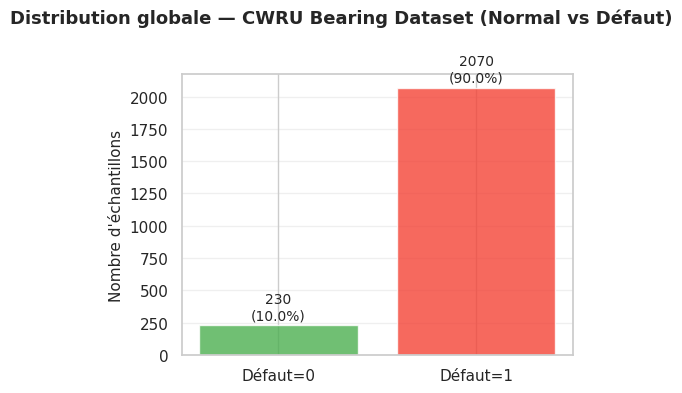

✓ Sauvegardé : figures/eda/cwru/class_distribution.png


In [3]:
# --- Figure 1 : distribution globale Normal vs Défaillant ---
fig = plot_label_distribution(
    df,
    label_col="label",
    label_name="Défaut",
    title="Distribution globale — CWRU Bearing Dataset (Normal vs Défaut)",
)
fig.savefig(FIGURES_DIR / "class_distribution.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'class_distribution.png'}")

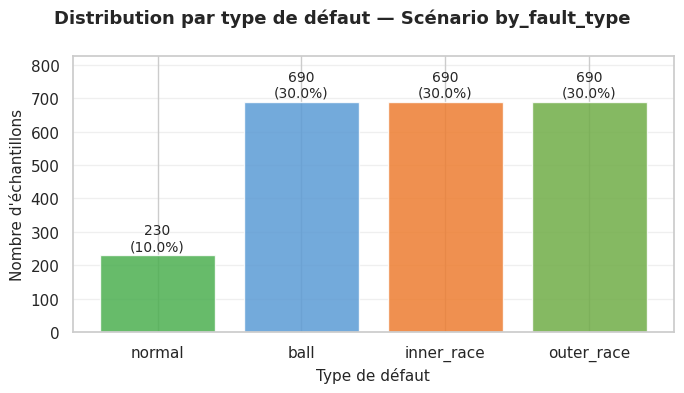

✓ Sauvegardé : figures/eda/cwru/class_by_fault_type.png


In [4]:
# --- Figure 2 : distribution par type de défaut (by_fault_type) ---
FAULT_TYPE_COLORS = {
    "normal": COLORS_LABEL[0],
    "ball": "#5B9BD5",
    "inner_race": "#ED7D31",
    "outer_race": "#70AD47",
}
fault_type_counts = df["fault_type"].value_counts()
order_ft = ["normal", "ball", "inner_race", "outer_race"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    order_ft,
    [fault_type_counts.get(k, 0) for k in order_ft],
    color=[FAULT_TYPE_COLORS[k] for k in order_ft],
    alpha=0.85,
    edgecolor="white",
)
for bar in bars:
    n = int(bar.get_height())
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        n + 5,
        f"{n}\n({n/len(df):.1%})",
        ha="center",
        va="bottom",
        fontsize=FIGURE_FONT_SIZE - 1,
    )
ax.set_xlabel("Type de défaut", fontsize=FIGURE_FONT_SIZE)
ax.set_ylabel("Nombre d'échantillons", fontsize=FIGURE_FONT_SIZE)
ax.set_ylim(0, fault_type_counts.max() * 1.2)
ax.grid(True, axis="y", alpha=0.3)
fig.suptitle(
    "Distribution par type de défaut — Scénario by_fault_type",
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_by_fault_type.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'class_by_fault_type.png'}")

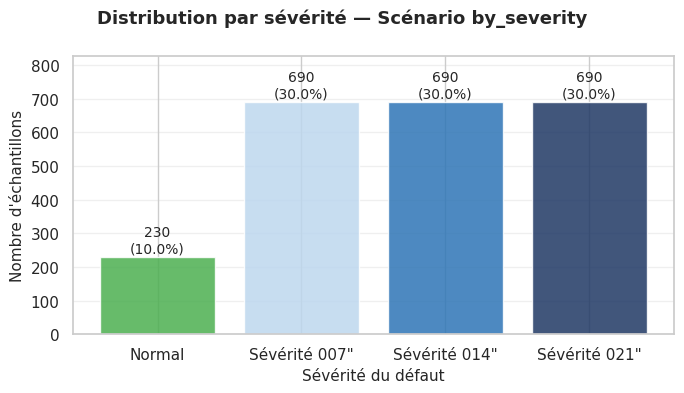

✓ Sauvegardé : figures/eda/cwru/class_by_severity.png


In [5]:
# --- Figure 3 : distribution par sévérité (by_severity) ---
SEVERITY_COLORS = {
    "normal": COLORS_LABEL[0],
    "007": "#BDD7EE",
    "014": "#2E75B6",
    "021": "#1F3864",
}
severity_counts = df["severity"].value_counts()
order_sev = ["normal", "007", "014", "021"]

fig, ax = plt.subplots(figsize=(7, 4))
bars = ax.bar(
    [f'Sévérité {k}"' if k != "normal" else "Normal" for k in order_sev],
    [severity_counts.get(k, 0) for k in order_sev],
    color=[SEVERITY_COLORS[k] for k in order_sev],
    alpha=0.85,
    edgecolor="white",
)
for bar in bars:
    n = int(bar.get_height())
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        n + 5,
        f"{n}\n({n/len(df):.1%})",
        ha="center",
        va="bottom",
        fontsize=FIGURE_FONT_SIZE - 1,
    )
ax.set_xlabel("Sévérité du défaut", fontsize=FIGURE_FONT_SIZE)
ax.set_ylabel("Nombre d'échantillons", fontsize=FIGURE_FONT_SIZE)
ax.set_ylim(0, severity_counts.max() * 1.2)
ax.grid(True, axis="y", alpha=0.3)
fig.suptitle(
    "Distribution par sévérité — Scénario by_severity",
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "class_by_severity.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'class_by_severity.png'}")

---
## Section 4 — Statistiques descriptives

In [6]:
# Statistiques par classe (Normal / Défaut)
stats_by_class = df.groupby("label")[FEATURE_COLS].describe().round(4)
print("Statistiques descriptives par classe (label 0=Normal, 1=Défaut) :")
display(stats_by_class.head(16))

Statistiques descriptives par classe (label 0=Normal, 1=Défaut) :


max                                                             min  \
        count    mean     std     min     25%     50%     75%     max   count   
label                                                                           
0       230.0  0.2051  0.0190  0.1573  0.1919  0.2029  0.2165  0.2641   230.0   
1      2070.0  1.7273  1.5926  0.2474  0.5098  0.9372  2.4626  6.8259  2070.0   

               ...   crest            form                                    \
         mean  ...     75%     max   count     mean      std     min     25%   
label          ...                                                             
0     -0.2065  ...  3.2666  3.8362   230.0   5.5293   1.1677  3.4844  4.6287   
1     -1.7004  ...  4.9193  8.8216  2070.0  28.8798  29.8890  4.8691  8.9761   

                                   
           50%      75%       max  
label                              
0       5.4340   6.3202   11.7021  
1      13.8481  44.1502  313.7426  

[2 rows x 72 columns]

/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(label_labels, fontsize=FIGURE_FONT_SIZE - 1)
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/home/leonard/Documents/ENAC/cl-embedded/notebooks/../src/evaluation/eda_plots.py:91: UserWarning: set_ticklabels() should only be used with a fixed num

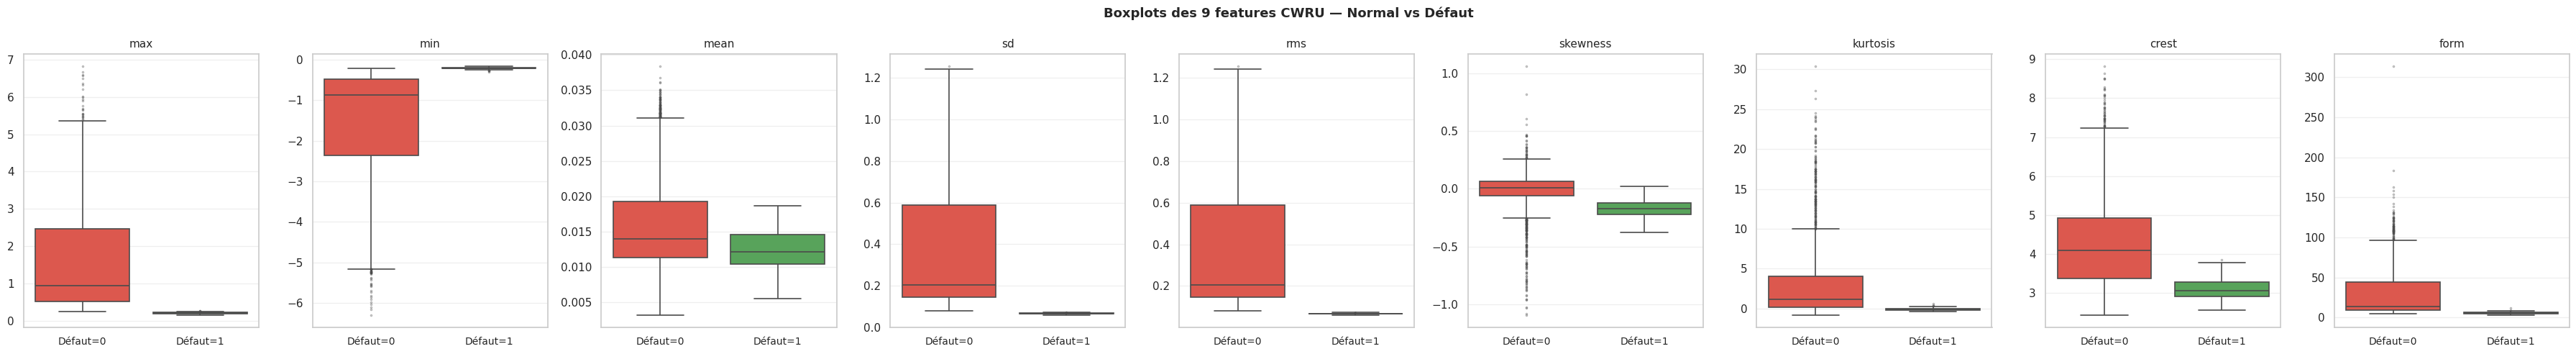

✓ Sauvegardé : figures/eda/cwru/boxplot_features_by_class.png


In [7]:
# --- Figure 4 : boxplots des 9 features par classe ---
fig = plot_boxplots_by_label(
    df,
    feature_cols=FEATURE_COLS,
    label_col="label",
    label_name="Défaut",
    title="Boxplots des 9 features CWRU — Normal vs Défaut",
)
fig.savefig(FIGURES_DIR / "boxplot_features_by_class.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'boxplot_features_by_class.png'}")

---
## Section 5 — Corrélations (Spearman)

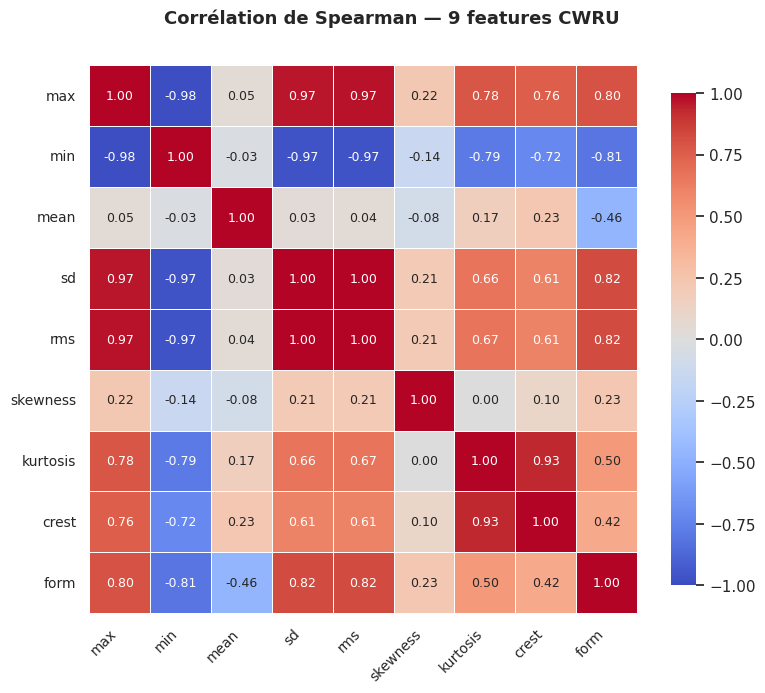

✓ Sauvegardé : figures/eda/cwru/correlation_heatmap.png


In [8]:
# --- Figure 5 : heatmap Spearman 9×9 ---
corr_spearman = df[FEATURE_COLS].corr(method="spearman")

fig, ax = plt.subplots(figsize=(8, 7))
sns.heatmap(
    corr_spearman,
    ax=ax,
    annot=True,
    fmt=".2f",
    annot_kws={"size": 9},
    cmap="coolwarm",
    center=0,
    vmin=-1,
    vmax=1,
    square=True,
    linewidths=0.4,
    cbar_kws={"shrink": 0.85},
)
ax.set_xticklabels(FEATURE_COLS, rotation=45, ha="right", fontsize=FIGURE_FONT_SIZE - 1)
ax.set_yticklabels(FEATURE_COLS, rotation=0, fontsize=FIGURE_FONT_SIZE - 1)
fig.suptitle(
    "Corrélation de Spearman — 9 features CWRU",
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "correlation_heatmap.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'correlation_heatmap.png'}")

---
## Section 6 — Scénario by_fault_type

Shift de distribution des features entre les 3 tâches : Ball → Inner Race → Outer Race.
Visualisation sur 3 features discriminantes : `rms`, `kurtosis`, `crest`.

In [9]:
# Construction du DataFrame par tâche (by_fault_type)
stream_ft = CWRUFaultTypeStream(dataset)
task_dfs_ft = {}
for task_id, task_name, X_task, y_task in stream_ft.iter_tasks():
    tdf = pd.DataFrame(X_task, columns=FEATURE_COLS)
    tdf["label"] = y_task.astype(int)
    tdf["task"] = task_name
    task_dfs_ft[task_name] = tdf
    print(f"  Task {task_id} ({task_name}) : {X_task.shape[0]} échantillons "
          f"({int(y_task.sum())} défaut, {int((1-y_task).sum())} normal)")
df_fault_type = pd.concat(task_dfs_ft.values(), ignore_index=True)

  Task 0 (ball) : 767 échantillons (690 défaut, 77 normal)
  Task 1 (inner_race) : 767 échantillons (690 défaut, 77 normal)
  Task 2 (outer_race) : 766 échantillons (690 défaut, 76 normal)


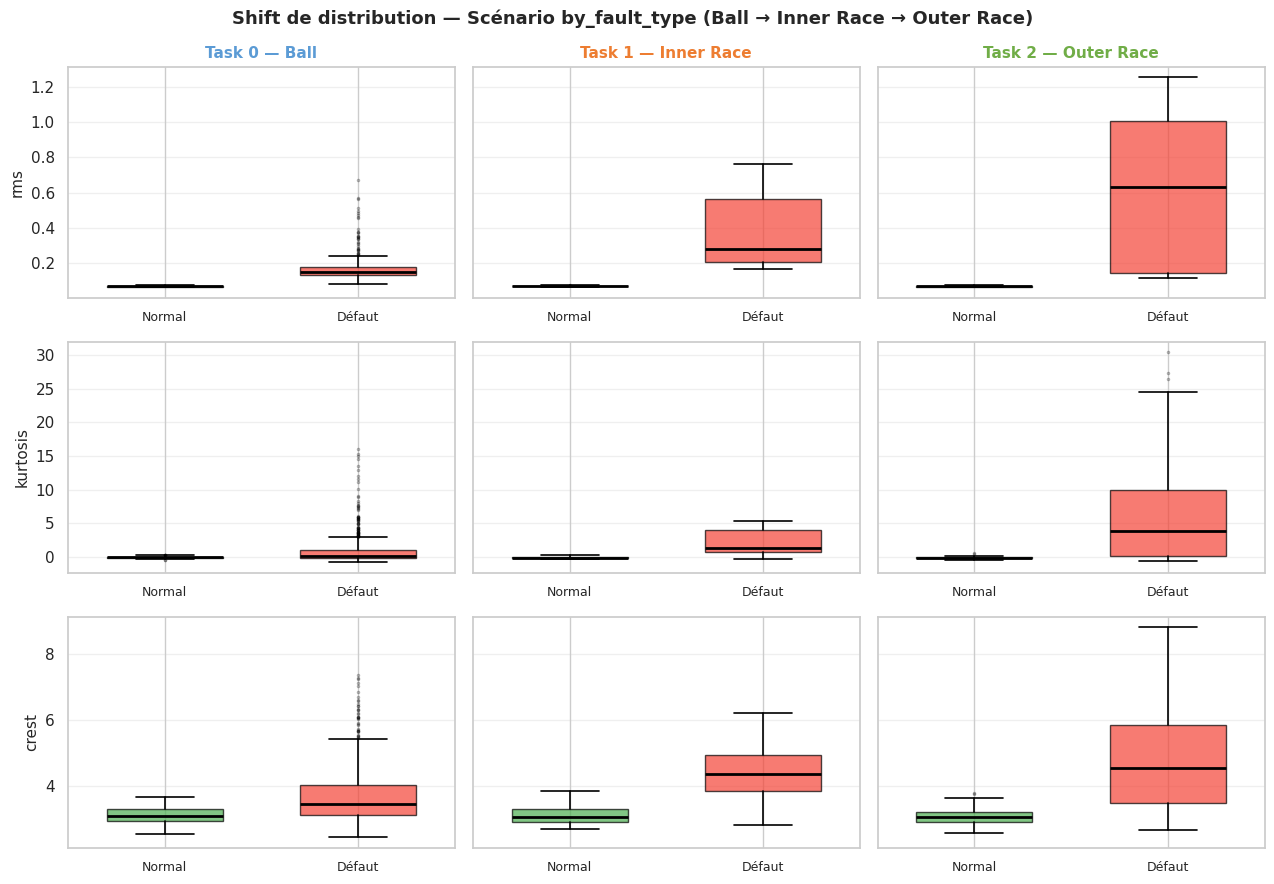

✓ Sauvegardé : figures/eda/cwru/domain_shift_fault_type.png


In [10]:
# --- Figure 9 : domain shift by_fault_type ---
KEY_FEATURES = ["rms", "kurtosis", "crest"]
TASK_ORDER_FT = FAULT_TYPE_ORDER  # ["ball", "inner_race", "outer_race"]
TASK_COLORS_FT = {"ball": "#5B9BD5", "inner_race": "#ED7D31", "outer_race": "#70AD47"}
TASK_LABELS_FT = {"ball": "Task 0 — Ball", "inner_race": "Task 1 — Inner Race", "outer_race": "Task 2 — Outer Race"}

fig, axes = plt.subplots(len(KEY_FEATURES), len(TASK_ORDER_FT), figsize=(13, 9), sharey="row")

for col_idx, task_name in enumerate(TASK_ORDER_FT):
    tdf = task_dfs_ft[task_name]
    for row_idx, feat in enumerate(KEY_FEATURES):
        ax = axes[row_idx][col_idx]
        for label_val, label_str, color in [
            (0, "Normal", COLORS_LABEL[0]),
            (1, "Défaut", COLORS_LABEL[1]),
        ]:
            vals = tdf[tdf["label"] == label_val][feat]
            ax.boxplot(
                vals,
                positions=[label_val],
                widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker=".", markersize=3, alpha=0.3, color=color),
            )
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Normal", "Défaut"], fontsize=FIGURE_FONT_SIZE - 2)
        ax.grid(True, axis="y", alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(feat, fontsize=FIGURE_FONT_SIZE)
        if row_idx == 0:
            ax.set_title(TASK_LABELS_FT[task_name], fontsize=FIGURE_FONT_SIZE,
                         color=TASK_COLORS_FT[task_name], fontweight="bold")

fig.suptitle(
    "Shift de distribution — Scénario by_fault_type (Ball → Inner Race → Outer Race)",
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "domain_shift_fault_type.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'domain_shift_fault_type.png'}")

---
## Section 7 — Scénario by_severity

Gradient de sévérité : 0.007" → 0.014" → 0.021" (diamètre de la fissure artificielle).
On s'attend à une augmentation progressive des features vibratoires avec la sévérité.

In [11]:
# Construction du DataFrame par tâche (by_severity)
stream_sev = CWRUSeverityStream(dataset)
task_dfs_sev = {}
for task_id, task_name, X_task, y_task in stream_sev.iter_tasks():
    tdf = pd.DataFrame(X_task, columns=FEATURE_COLS)
    tdf["label"] = y_task.astype(int)
    tdf["task"] = task_name
    task_dfs_sev[task_name] = tdf
    print(f"  Task {task_id} ({task_name}\") : {X_task.shape[0]} échantillons "
          f"({int(y_task.sum())} défaut, {int((1-y_task).sum())} normal)")
df_severity = pd.concat(task_dfs_sev.values(), ignore_index=True)

  Task 0 (007") : 767 échantillons (690 défaut, 77 normal)
  Task 1 (014") : 767 échantillons (690 défaut, 77 normal)
  Task 2 (021") : 766 échantillons (690 défaut, 76 normal)


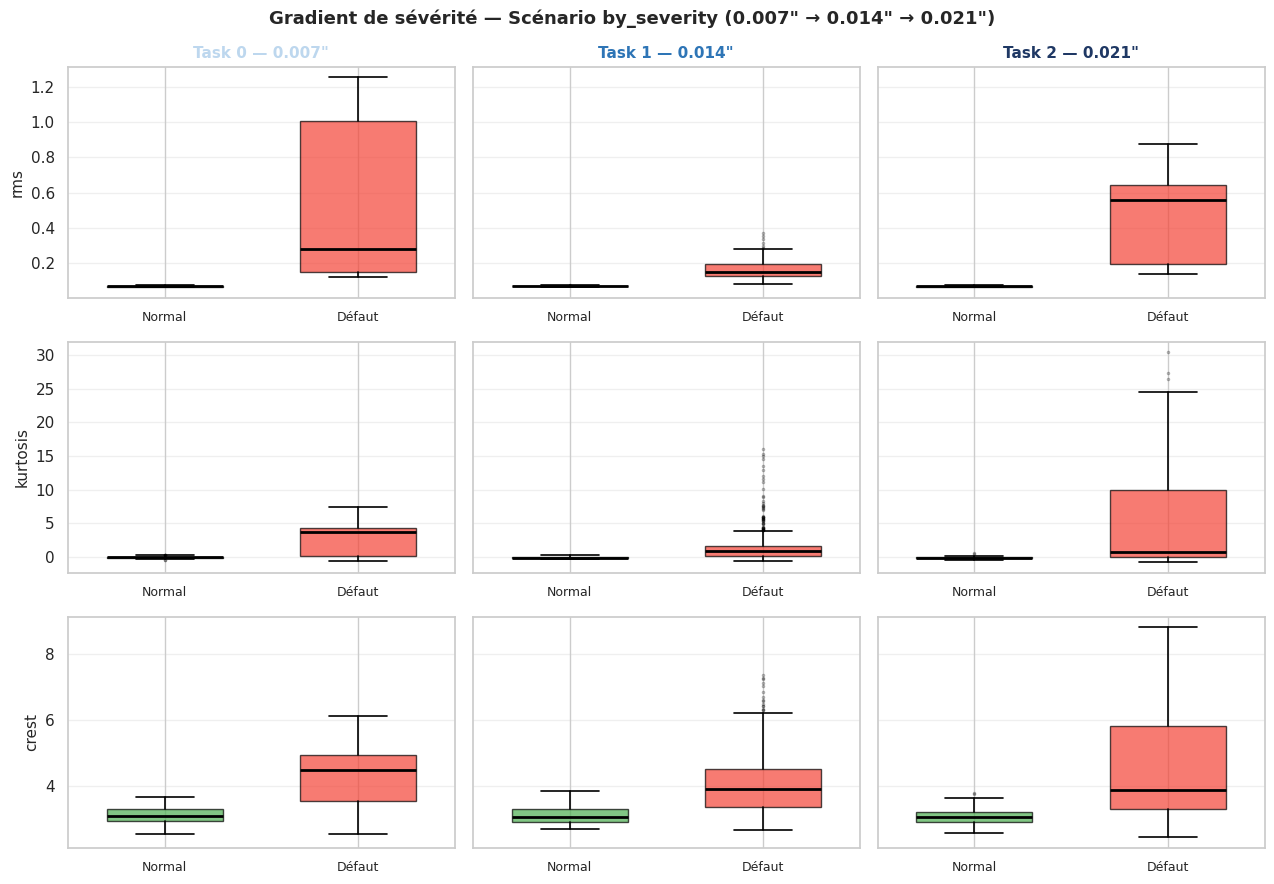

✓ Sauvegardé : figures/eda/cwru/domain_shift_severity.png


In [12]:
# --- Figure 10 : domain shift by_severity ---
TASK_ORDER_SEV = SEVERITY_ORDER  # ["007", "014", "021"]
SEVERITY_GRAD_COLORS = {"007": "#BDD7EE", "014": "#2E75B6", "021": "#1F3864"}
TASK_LABELS_SEV = {"007": 'Task 0 — 0.007"', "014": 'Task 1 — 0.014"', "021": 'Task 2 — 0.021"'}

fig, axes = plt.subplots(len(KEY_FEATURES), len(TASK_ORDER_SEV), figsize=(13, 9), sharey="row")

for col_idx, task_name in enumerate(TASK_ORDER_SEV):
    tdf = task_dfs_sev[task_name]
    for row_idx, feat in enumerate(KEY_FEATURES):
        ax = axes[row_idx][col_idx]
        for label_val, label_str, color in [
            (0, "Normal", COLORS_LABEL[0]),
            (1, "Défaut", COLORS_LABEL[1]),
        ]:
            vals = tdf[tdf["label"] == label_val][feat]
            ax.boxplot(
                vals,
                positions=[label_val],
                widths=0.6,
                patch_artist=True,
                boxprops=dict(facecolor=color, alpha=0.7),
                medianprops=dict(color="black", linewidth=2),
                whiskerprops=dict(linewidth=1.2),
                capprops=dict(linewidth=1.2),
                flierprops=dict(marker=".", markersize=3, alpha=0.3, color=color),
            )
        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Normal", "Défaut"], fontsize=FIGURE_FONT_SIZE - 2)
        ax.grid(True, axis="y", alpha=0.3)
        if col_idx == 0:
            ax.set_ylabel(feat, fontsize=FIGURE_FONT_SIZE)
        if row_idx == 0:
            ax.set_title(
                TASK_LABELS_SEV[task_name],
                fontsize=FIGURE_FONT_SIZE,
                color=SEVERITY_GRAD_COLORS[task_name],
                fontweight="bold",
            )

fig.suptitle(
    'Gradient de sévérité — Scénario by_severity (0.007" → 0.014" → 0.021")',
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "domain_shift_severity.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'domain_shift_severity.png'}")

---
## Section 8 — Séparabilité (PCA 2D)

Projection Z-score + PCA sur 2 composantes principales.
Trois vues : colorée par label, par type de défaut, par sévérité.

In [13]:
# Normalisation Z-score + PCA
scaler = StandardScaler()
X_scaled = scaler.fit_transform(dataset.X)

pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

var_explained = pca.explained_variance_ratio_
print(f"Variance expliquée : PC1={var_explained[0]:.1%}, PC2={var_explained[1]:.1%}, "
      f"Total={var_explained.sum():.1%}")

# Annotations PCA pour chaque point
y_label = dataset.y.astype(int)
y_fault_type = df["fault_type"].values
y_severity = df["severity"].values

Variance expliquée : PC1=60.7%, PC2=19.3%, Total=80.0%


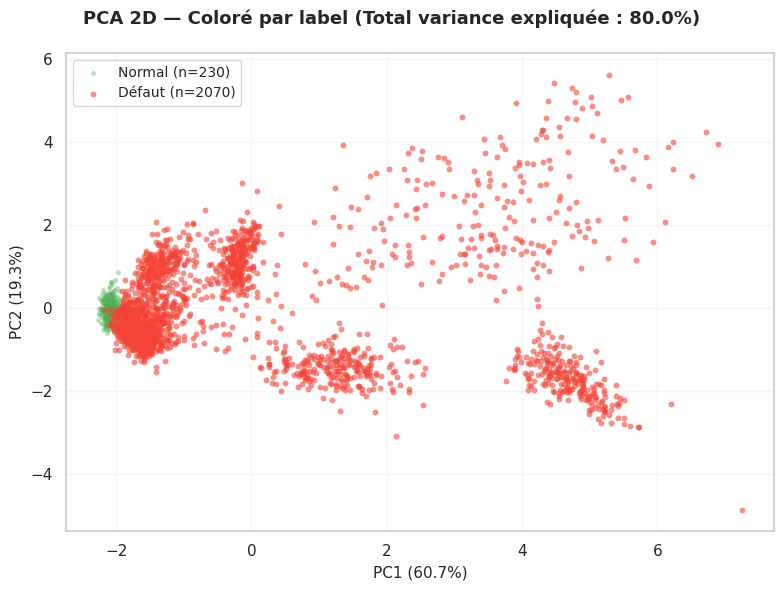

✓ Sauvegardé : figures/eda/cwru/pca_2d_by_class.png


In [14]:
# --- Figure 6 : PCA colorée par label ---
fig, ax = plt.subplots(figsize=(8, 6))
for v, name in [(0, "Normal"), (1, "Défaut")]:
    mask = y_label == v
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=COLORS_LABEL[v],
        alpha=0.4 if v == 0 else 0.6,
        s=12 if v == 0 else 18,
        linewidths=0,
        label=f"{name} (n={mask.sum()})",
        zorder=2 if v == 1 else 1,
    )
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%})", fontsize=FIGURE_FONT_SIZE)
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%})", fontsize=FIGURE_FONT_SIZE)
ax.legend(fontsize=FIGURE_FONT_SIZE - 1)
ax.grid(True, alpha=0.2)
fig.suptitle(
    f"PCA 2D — Coloré par label (Total variance expliquée : {var_explained.sum():.1%})",
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_2d_by_class.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'pca_2d_by_class.png'}")

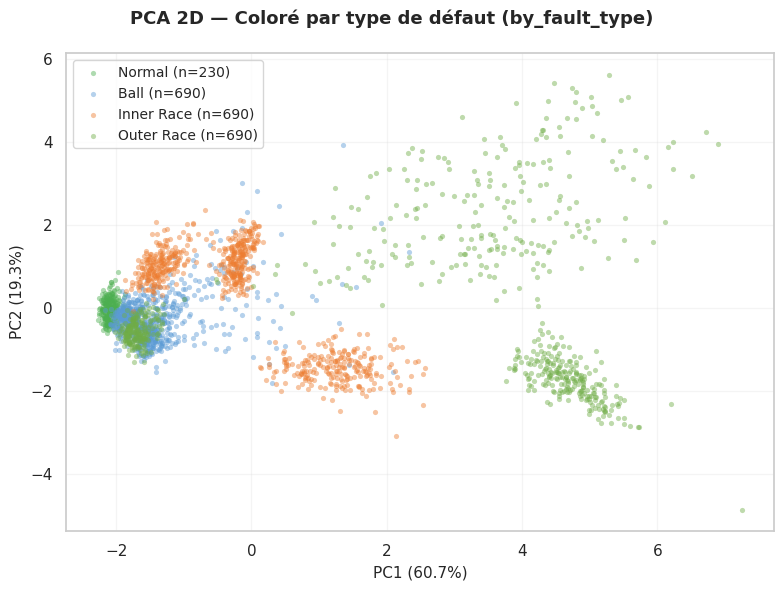

✓ Sauvegardé : figures/eda/cwru/pca_2d_by_fault_type.png


In [15]:
# --- Figure 7 : PCA colorée par type de défaut ---
FAULT_TYPE_PCA_COLORS = {
    "normal": COLORS_LABEL[0],
    "ball": "#5B9BD5",
    "inner_race": "#ED7D31",
    "outer_race": "#70AD47",
}
FAULT_TYPE_LABELS_DISPLAY = {
    "normal": "Normal",
    "ball": "Ball",
    "inner_race": "Inner Race",
    "outer_race": "Outer Race",
}

fig, ax = plt.subplots(figsize=(8, 6))
for ft in ["normal", "ball", "inner_race", "outer_race"]:
    mask = y_fault_type == ft
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=FAULT_TYPE_PCA_COLORS[ft],
        alpha=0.45,
        s=14,
        linewidths=0,
        label=f"{FAULT_TYPE_LABELS_DISPLAY[ft]} (n={mask.sum()})",
    )
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%})", fontsize=FIGURE_FONT_SIZE)
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%})", fontsize=FIGURE_FONT_SIZE)
ax.legend(fontsize=FIGURE_FONT_SIZE - 1)
ax.grid(True, alpha=0.2)
fig.suptitle(
    "PCA 2D — Coloré par type de défaut (by_fault_type)",
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_2d_by_fault_type.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'pca_2d_by_fault_type.png'}")

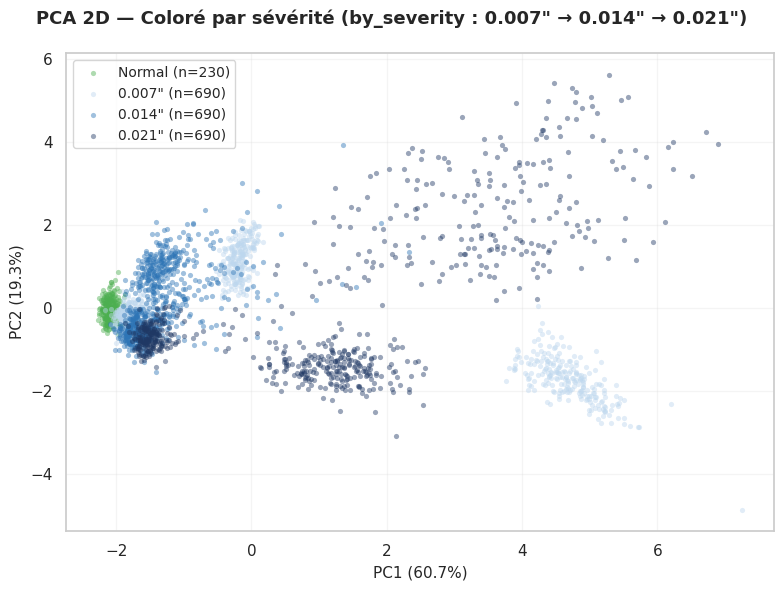

✓ Sauvegardé : figures/eda/cwru/pca_2d_by_severity.png


In [16]:
# --- Figure 8 : PCA colorée par sévérité ---
SEV_PCA_COLORS = {
    "normal": COLORS_LABEL[0],
    "007": "#BDD7EE",
    "014": "#2E75B6",
    "021": "#1F3864",
}
SEV_LABELS_DISPLAY = {
    "normal": "Normal",
    "007": '0.007"',
    "014": '0.014"',
    "021": '0.021"',
}

fig, ax = plt.subplots(figsize=(8, 6))
for sev in ["normal", "007", "014", "021"]:
    mask = y_severity == sev
    ax.scatter(
        X_pca[mask, 0], X_pca[mask, 1],
        c=SEV_PCA_COLORS[sev],
        alpha=0.45,
        s=14,
        linewidths=0,
        label=f"{SEV_LABELS_DISPLAY[sev]} (n={mask.sum()})",
    )
ax.set_xlabel(f"PC1 ({var_explained[0]:.1%})", fontsize=FIGURE_FONT_SIZE)
ax.set_ylabel(f"PC2 ({var_explained[1]:.1%})", fontsize=FIGURE_FONT_SIZE)
ax.legend(fontsize=FIGURE_FONT_SIZE - 1)
ax.grid(True, alpha=0.2)
fig.suptitle(
    'PCA 2D — Coloré par sévérité (by_severity : 0.007" → 0.014" → 0.021")',
    fontsize=FIGURE_FONT_SIZE + 2,
    fontweight="bold",
)
fig.tight_layout()
fig.savefig(FIGURES_DIR / "pca_2d_by_severity.png", dpi=FIGURE_DPI, bbox_inches="tight")
plt.show()
print(f"✓ Sauvegardé : {FIGURES_DIR / 'pca_2d_by_severity.png'}")

---
## Section 9 — Comparaison avec PRONOSTIA

Tableau de bord comparatif entre les deux datasets de roulements utilisés dans le projet.

In [17]:
n_samples_cwru = len(df)
n_fault_cwru = int(df["label"].sum())
n_normal_cwru = n_samples_cwru - n_fault_cwru
imbalance_cwru = n_fault_cwru / n_samples_cwru

comparison_data = {
    "Métrique": [
        "N échantillons (fenêtres)",
        "N features",
        "N classes (label binaire)",
        "Taux défaillant",
        "Déséquilibre",
        "Type de scénario CL",
        "N tâches",
        "Critère de split",
        "Source du signal",
        "Fréquence d'échantillonnage",
        "Taille de fenêtre",
        "Features extraites",
    ],
    "CWRU Bearing": [
        f"{n_samples_cwru} (2300)",
        "9 (stat. temporelles)",
        "2 (Normal / Défaut)",
        f"{imbalance_cwru:.1%} ({n_fault_cwru}/{n_samples_cwru})",
        "Faible — majorité fautive",
        "Domain-Incremental",
        "3 (fault_type OU severity)",
        "Type de défaut OU sévérité",
        "Vibration 1D (accéléromètre)",
        "48 kHz",
        "2048 points (42 ms)",
        "max, min, mean, sd, rms, skewness, kurtosis, crest, form",
    ],
    "PRONOSTIA (IEEE PHM 2012)": [
        "7534 (fenêtres 2560 pts)",
        "13 (12 acc + 1 temporelle)",
        "2 (Normal / Pré-failure)",
        "~10% (10% terminaux)",
        "Fort — 90% normal, 10% failure",
        "Domain-Incremental",
        "3 (conditions opératoires)",
        "RPM + charge mécanique",
        "Accélération 2D (horiz + vert)",
        "25.6 kHz",
        "2560 points (100 ms)",
        "mean, std, rms, kurtosis, peak, crest_factor × 2 canaux",
    ],
}

df_comparison = pd.DataFrame(comparison_data).set_index("Métrique")
print("Tableau comparatif CWRU vs PRONOSTIA :")
display(df_comparison)

Tableau comparatif CWRU vs PRONOSTIA :


,CWRU Bearing,PRONOSTIA (IEEE PHM 2012)
Métrique,,
N échantillons (fenêtres),2300 (2300),7534 (fenêtres 2560 pts)
N features,9 (stat. temporelles),13 (12 acc + 1 temporelle)
N classes (label binaire),2 (Normal / Défaut),2 (Normal / Pré-failure)
Taux défaillant,90.0% (2070/2300),~10% (10% terminaux)
Déséquilibre,Faible — majorité fautive,"Fort — 90% normal, 10% failure"
Type de scénario CL,Domain-Incremental,Domain-Incremental
N tâches,3 (fault_type OU severity),3 (conditions opératoires)
Critère de split,Type de défaut OU sévérité,RPM + charge mécanique
Source du signal,Vibration 1D (accéléromètre),Accélération 2D (horiz + vert)


---
## Observations

### Section 2 — Vue d'ensemble
- 2300 fenêtres × 9 features, aucune valeur manquante. 10 classes équilibrées (230 fenêtres chacune). Le dataset est dominé par les échantillons défaillants (~90%).

### Section 3 — Distribution des labels
- Les 3 types de défauts (Ball, IR, OR) sont parfaitement équilibrés (690 fautifs chacun). Les 3 niveaux de sévérité aussi (690 chacun). L'ensemble des normaux = 230 échantillons (10%).

### Section 4 — Statistiques descriptives
- `rms`, `max`, `crest` montrent la plus forte séparation entre Normal et Défaut. `mean` et `min` sont peu discriminants (signal centré). `kurtosis` apporte une information impulsionnelle complémentaire.

### Section 5 — Corrélations
- `rms`, `max`, `min` sont fortement corrélés entre eux. `skewness` et `kurtosis` apportent une dimension indépendante. `crest` et `form` sont partiellement redondants.

### Section 6-7 — Shifts de domaine
- Le shift entre types de défauts (ball vs IR vs OR) est visible sur `kurtosis` et `crest` — les défauts de bague externe (OR) ont un profil vibratoire distinct. La progression de sévérité est plus subtile mais observable sur `rms` (augmentation monotone 007→014→021 pour les échantillons fautifs). **Validation du scénario Domain-Incremental.**

### Section 8 — PCA
- Les échantillons défaillants forment un cluster distinct des normaux sur PC1. Les types de défauts (Ball/IR/OR) montrent une séparation partielle — les défauts OR se distinguent mieux. La sévérité est moins séparable en 2D (les 3 niveaux se superposent).

### Section 9 — Comparaison PRONOSTIA
- CWRU est complémentaire à PRONOSTIA : déséquilibre inversé (majorité fautive vs 10% pré-failure), scénarios CL différents (fault type/severity vs condition opératoire), signal vibratoire 1D vs 2D. **Implication Gap 1** : la combinaison des deux datasets couvre deux modalités industrielles distinctes de défaillance de roulements.